# Práctica 3 - Ejercicio 2

Asignatura: Programación para la Inteligencia Artificial

Alumno: Jose Francisco Aguilar Granados


Uno de los primeros modelos propuestos para la generación de datos usando Aprendizaje profundo fue el *Variational Autoencoder* (VAE).

Un VAE es una red autocodificadora que durante su entrenamiento, en lugar de codificar a un espacio latente de manera determinista (cada ejemplo tiene asociada una codificación), asocia distribuciones gaussianas que se muestrean para obtener una codificación que seguidamente se decodifica. Por tanto, el proceso queda como sigue:

$$\mu, \sigma^2 = e_{\theta_1}(x)$$

$$z \sim \mathcal{N}(\mu, \sigma^2) $$

$$y = d_{\theta_{2}} (z)$$

Para realizar el entrenamiento como cualquier red autocodificadora, se incluye una función de pérdida de reconstrucción:

$$L_{r}(x,y)$$

Pero además se añade una función de pérdida con el objetivo de regularizar las distribuciones gaussianas que pueden aprenderse. Para esto se usa la Divergencia de Kullback-Leibler, que mide el grado de disimilitud entre una distribución de probabilidad $Q$ respecto a una distribución de probabilidad $P$:

$$D_{KL}(P,Q) = \sum_{x \in X} P(x) log (\frac{P(x)}{Q(x)})$$

La divergencia KL se utiliza para penalizar que las distribuciones gaussianas se alejen de la distribución gaussiana de media 0 y varianza 1 ($\mathcal{N}(0, 1)$). Teniendo eso en cuenta, su formulación se puede simplificar a:

$$L_{KL}(\mu, \sigma)= \sum_{i=0}^n -\frac{1}{2}(1+log (\sigma_i^2) - \mu_i^2 - \sigma_i^2)$$

Siendo la función de pérdida que se usa durante el entrenamiento:

$$L = L_{r} + \alpha L_{KL}$$

con $\alpha$ un hiperparámetro que controla cuánto peso tiene la divergencia de Kullback-Leibler respecto a la pérdida de reconstrucción.

Tras implementar el VAE, se pide entrenarlo para los datos de  Fashion-MNIST con un espacio latente de 8 dimensiones (el vector $\mu$ y el que representa sus respectivas varianzas tienen 8 dimensiones cada uno). Una vez entrenado y comprobado debidamente que funciona, se pide mostrar las componentes del vector $\mu$ del conjunto de test en el espacio latente usando gráficas bidimensionales que indican la clase de cada ejemplo como en el Ejercicio 1.

Después, se debe extraer el vector prototípico para cada clase en el conjunto de test (la media de los vectores $\mu$ para cada clase) y mostrar las imágenes generadas por el decodificador a partir de las codificaciones interpoladas entre los vectores prototípicos de dos clases cualesquiera.

El cuaderno entregado debe llamarse ApellidosNombrePractica3Ejercicio2.ipynb

Notas:
 * Para realizar el muestreo $z$ permitiendo la retropropagación del error se usa el "truco de reparametrización": no muestrear directamente la distribución gaussiana obtenida (eso rompería el grafo de cómputo), sino la distribución gaussiana $\hat{z} \sim \mathcal{N}(0, 1)$ y aprovechar la propiedad de las gaussianas para convertir el muestreo de una distribución gaussiana en el de otra para que (una vez simplificado aprovechando que se muestrea la normal) quede  $z =  \hat{z} \sigma + \mu$.
 * Es más fácil (y equivalente) que el encoder genere el logaritmo de la varianza en lugar de la varianza. Así se evita la posibilidad de intentar computar un $log(0)$. Obviamente hay que ajustar las fórmulas que se implementan de manera acorde.
 * Aunque PyTorch implementa diversas funciones para calcular la divergencia KL, ninguna está directamente pensada para este uso y su aplicación no es directa, así que es más fácil simplemente implementarla. Hay que recordar usar los operadores de PyTorch para que se genere el grafo de cómputo sin problema y que la pérdida de un lote debe ser la media de las pérdidas de los ejemplos que lo forman.
 * El valor $\alpha$ para conseguir un entrenamiento apropiado puede ser muy bajo según el conjunto de datos al que se aplique (incluso menos de 0.01).

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader,Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from google.colab import drive
import numpy as np

drive.mount('/content/drive')
workpath = '/content/drive/MyDrive/Work/Docencia UMA/2025-2026/Programacion para la IA/data'

train_dataset = datasets.FashionMNIST(root=workpath, train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.FashionMNIST(root=workpath, train=False, download=True, transform=transforms.ToTensor())
print(f"Número de ejemplos en entrenamiento: {len(train_dataset)}")
print(f"Número de ejemplos en test: {len(test_dataset)}")


Mounted at /content/drive
Número de ejemplos en entrenamiento: 60000
Número de ejemplos en test: 10000


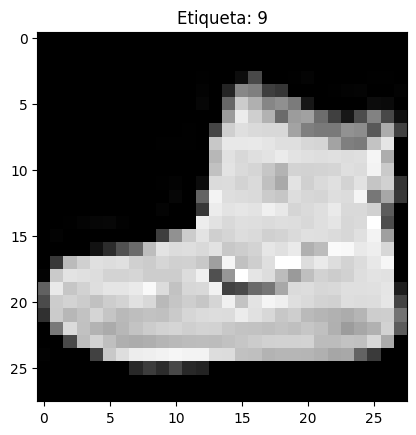

In [ ]:
image, label = train_dataset[0]
plt.imshow(np.transpose(image, (1, 2, 0)), cmap="gray")
plt.title(f"Etiqueta: {label}")
plt.show()

In [ ]:
def split_dataset(dataset, split_share=0.5):
  """
  Devuelve dos subconjuntos del dataset. split_share define cuántos ejemplos irán al
  primer subconjunto. El resto irán al segundo.
  """
  mask_indices_to_first_subset = torch.rand(len(dataset))<=split_share
  indices_first_subset = [i for i, (_, _) in enumerate(dataset) if mask_indices_to_first_subset[i]]
  indices_second_subset = [i for i, (_, _) in enumerate(dataset) if not mask_indices_to_first_subset[i]]

  first_subset = torch.utils.data.Subset(dataset, indices_first_subset)
  second_subset = torch.utils.data.Subset(dataset, indices_second_subset)

  return first_subset, second_subset

In [ ]:
val_dataset,train_dataset = split_dataset(train_dataset, split_share=0.1)

print(f"Número de ejemplos en entrenamiento: {len(train_dataset)}")
print(f"Número de ejemplos en validación: {len(val_dataset)}")
print(f"Número de ejemplos en test: {len(test_dataset)}")

Número de ejemplos en entrenamiento: 53928
Número de ejemplos en validación: 6072
Número de ejemplos en test: 10000


In [ ]:
def learning_loop_vae(train_dataloader, val_dataloader, model, epochs, loss_fn, learning_rate, optimizer, alpha=0.01):
    train_loss_list = []
    val_loss_list = []
    opt = optimizer(
        model.parameters(),
        lr=learning_rate
    )

    for epoch in tqdm(range(epochs), desc="epoch:"):
        train_step_loss_list = []

        for x_train_true, _ in train_dataloader:

            recon_batch, mu, logvar = model(x_train_true)
            opt.zero_grad()

            recon_loss = loss_fn(recon_batch, x_train_true)

            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

            kl_loss = kl_loss / x_train_true.size(0)


            loss = recon_loss + (alpha * kl_loss)

            loss.backward()
            train_step_loss_list.append(loss.clone().detach())
            opt.step()

        train_loss_list.append(torch.tensor(train_step_loss_list).mean())

        # Validación cada 10 épocas
        if epoch % 10 == 0:
            val_step_loss_list = []
            with torch.no_grad():
                for x_val_true, _ in val_dataloader:
                    # Aplicamos la misma lógica que en el train
                    recon_val, mu_val, logvar_val = model(x_val_true)

                    recon_loss_val = loss_fn(recon_val, x_val_true)

                    kl_loss_val = -0.5 * torch.sum(1 + logvar_val - mu_val.pow(2) - logvar_val.exp())
                    kl_loss_val = kl_loss_val / x_val_true.size(0)

                    loss_val = recon_loss_val + (alpha * kl_loss_val)

                    val_step_loss_list.append(loss_val)

            if val_step_loss_list:
                val_loss_list.append(torch.tensor(val_step_loss_list).mean())

    return model, train_loss_list, val_loss_list

In [ ]:
class CudaDataset(Dataset):
  def __init__(self, dataset, device, transform = None):
    self.dataset = dataset
    self.cuda_y = []
    self.cuda_x = []
    self.device = device
    self.transform = transform

    for x, y in tqdm(self.dataset, desc="Moving to GPU"):
      self.cuda_x.append(x.to(self.device))
      self.cuda_y.append(torch.tensor(y, device=self.device))

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    if self.transform is None:
      x = self.cuda_x[idx]
    else:
      x = self.transform(self.cuda_x[idx])
    return x, self.cuda_y[idx]


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")


batch_size = 1024
learning_rate = 1e-3
epochs = 200
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam

##################
gpu_train_dataset = CudaDataset(train_dataset, device)
gpu_val_dataset = CudaDataset(val_dataset, device)
##################
                                  ####
train_dataloader = DataLoader(gpu_train_dataset, batch_size = batch_size, shuffle=True)
val_dataloader = DataLoader(gpu_val_dataset, batch_size=batch_size, shuffle=True)

class VariationalAutoencoder(torch.nn.Module):
    def __init__(self, input_dim=784, latent_dim=8, output_shape=(1, 28, 28)):
        super(VariationalAutoencoder, self).__init__()
        self.output_shape = output_shape
        self.flatten = torch.nn.Flatten()

        self.encoder_body = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 64),
            torch.nn.ReLU()
        )

        # Dos cabezas separadas que salen de la capa de 64 neuronas
        self.fc_mu = torch.nn.Linear(64, latent_dim)      # Para la media
        self.fc_logvar = torch.nn.Linear(64, latent_dim)  # Para el log-varianza

        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, input_dim),
            torch.nn.Sigmoid(),
            torch.nn.Unflatten(1, output_shape)
        )

    def reparameterize(self, mu, logvar):

        if self.training:
            # Calcular la desviación estándar: std = exp(0.5 * log_var)
            std = torch.exp(0.5 * logvar)
            # Generar ruido aleatorio epsilon N(0,1) del mismo tamaño
            eps = torch.randn_like(std)
            # z = mu + sigma * epsilon
            return mu + eps * std
        else:
            # En inferencia (test), solemos usar directamente la media
            return mu

    def forward(self, x):
        x_flat = self.flatten(x)

        hidden = self.encoder_body(x_flat)
        mu = self.fc_mu(hidden)
        logvar = self.fc_logvar(hidden)

        z = self.reparameterize(mu, logvar)

        # Decodificamos z
        decoded = self.decoder(z)

        return decoded, mu, logvar

# Mover modelo a GPU
model = VariationalAutoencoder(input_dim=28*28, latent_dim=8)
model = model.to(device)
print(f"Modelo en: {next(model.parameters()).device}")


Usando dispositivo: cuda


Moving to GPU: 100%|██████████| 6072/6072 [00:01<00:00, 5364.09it/s]

Modelo en: cuda:0


In [ ]:
model, train_loss_list, val_loss_list = learning_loop_vae(
    train_dataloader, val_dataloader, model, epochs, loss_fn, learning_rate, optimizer
)

epoch:: 100%|██████████| 200/200 [01:16<00:00,  2.63it/s]


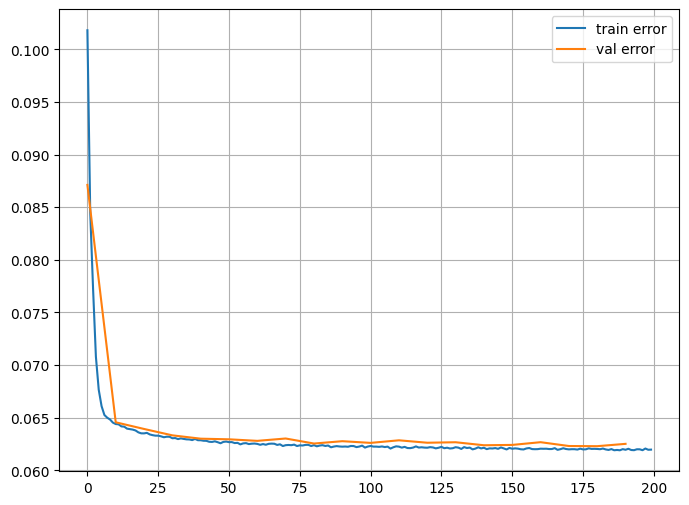

In [ ]:
def safe_convert(data):
        if isinstance(data, torch.Tensor):
            return data.cpu().detach().numpy() #como numpy no puede trabajar con gpu, lo cargamos en cpu. Detach desactiva los gradientes
        return data

train_loss_list = [safe_convert(x) for x in train_loss_list]
val_loss_list = [safe_convert(x) for x in val_loss_list]

plt.figure(figsize=(8,6))
plt.plot(range(len(train_loss_list)), train_loss_list, label="train error")
plt.plot(range(0, 10*len(val_loss_list), 10), val_loss_list, label="val error")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
gpu_test_dataset = CudaDataset(test_dataset, device)
test_dataloader = DataLoader(gpu_test_dataset, batch_size=batch_size, shuffle=False)


Moving to GPU: 100%|██████████| 10000/10000 [00:01<00:00, 5349.59it/s]


In [ ]:
mus_list = []
labels_list = []
for x_true, y_true in test_dataloader:
  salida,mu,logvar = model(x_true)
  mus_list.append(mu.cpu().detach().numpy())
  labels_list.append(y_true.cpu().detach().numpy())

mus_list = np.concatenate(mus_list, axis=0)
labels_list = np.concatenate(labels_list, axis=0)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

salida = [safe_convert(x) for x in salida]
#mu = [safe_convert(x) for x in mu]
logvar = [safe_convert(x) for x in logvar]
mus_list = [safe_convert(x) for x in mus_list]
labels_list = [safe_convert(x) for x in labels_list]

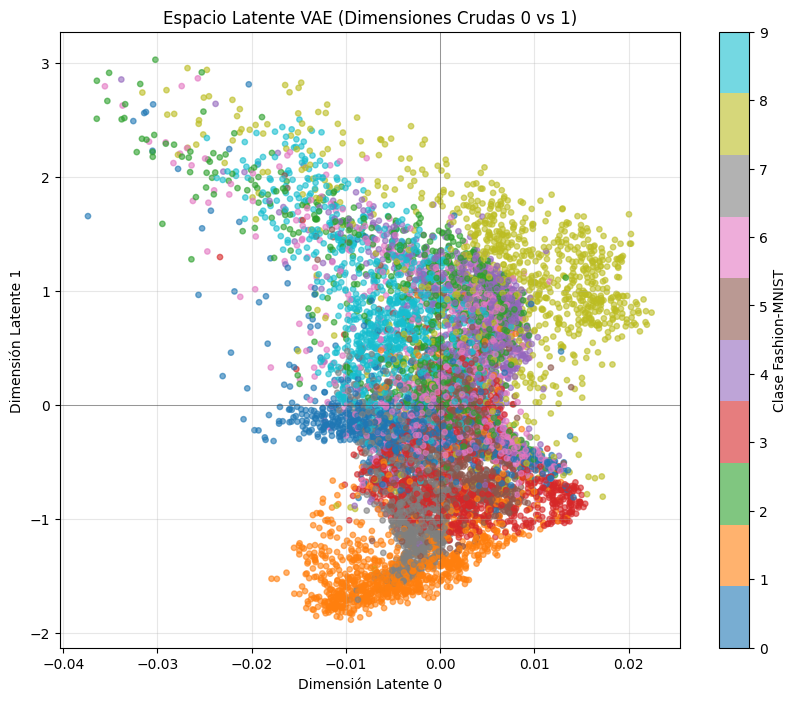

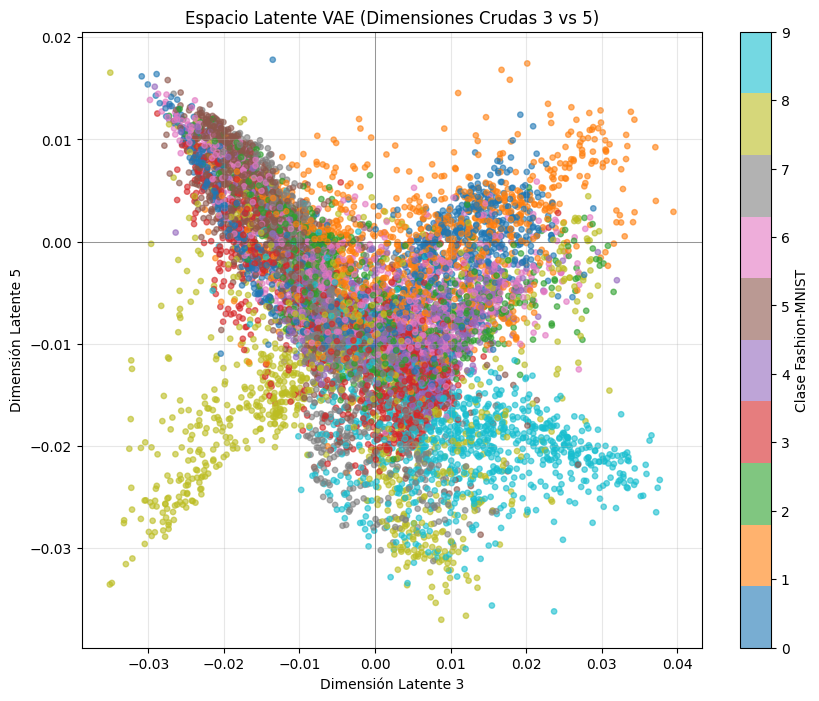

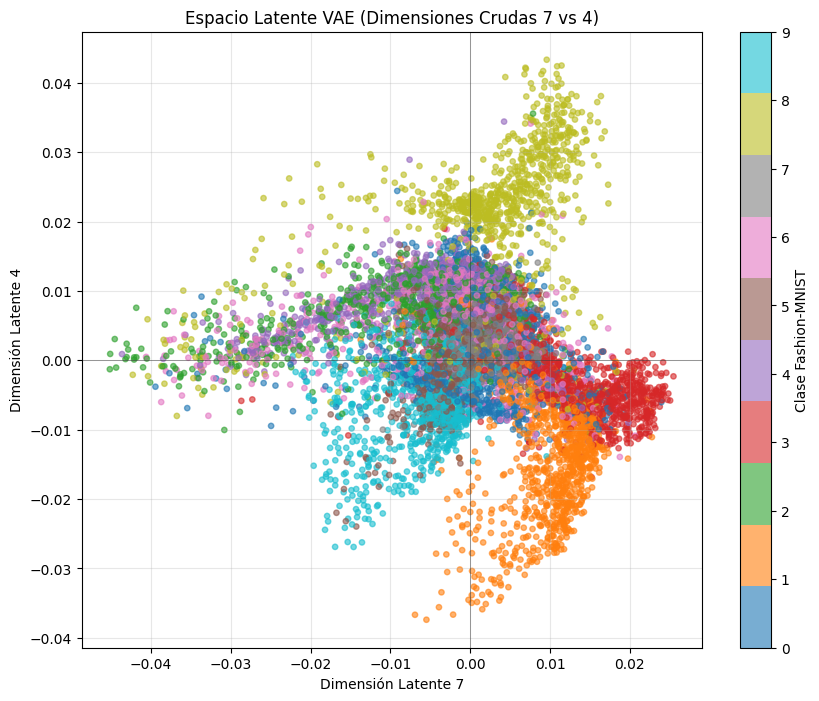

In [ ]:
mus_array = np.array(mus_list)
labels_array = np.array(labels_list)


x_coords = mus_array[:, 0]
y_coords = mus_array[:, 1]


plt.figure(figsize=(10, 8))


scatter = plt.scatter(x_coords, y_coords, c=labels_array, cmap='tab10', alpha=0.6, s=15)

# Añadimos la barra de colores para saber qué es cada cosa
cbar = plt.colorbar(scatter)
cbar.set_label('Clase Fashion-MNIST')

plt.title('Espacio Latente VAE (Dimensiones Crudas 0 vs 1)')
plt.xlabel('Dimensión Latente 0')
plt.ylabel('Dimensión Latente 1')
plt.grid(True, alpha=0.3)

# Opcional: Centrar la vista en (0,0) ya que es una Gaussiana normal
plt.axhline(0, color='black', linewidth=0.5, alpha=0.5)
plt.axvline(0, color='black', linewidth=0.5, alpha=0.5)

plt.show()


x_coords = mus_array[:, 3]
y_coords = mus_array[:, 5]


plt.figure(figsize=(10, 8))


scatter = plt.scatter(x_coords, y_coords, c=labels_array, cmap='tab10', alpha=0.6, s=15)

# Añadimos la barra de colores para saber qué es cada cosa
cbar = plt.colorbar(scatter)
cbar.set_label('Clase Fashion-MNIST')

plt.title('Espacio Latente VAE (Dimensiones Crudas 3 vs 5)')
plt.xlabel('Dimensión Latente 3')
plt.ylabel('Dimensión Latente 5')
plt.grid(True, alpha=0.3)

# Opcional: Centrar la vista en (0,0) ya que es una Gaussiana normal
plt.axhline(0, color='black', linewidth=0.5, alpha=0.5)
plt.axvline(0, color='black', linewidth=0.5, alpha=0.5)

plt.show()

x_coords = mus_array[:, 7]
y_coords = mus_array[:, 4]


plt.figure(figsize=(10, 8))


scatter = plt.scatter(x_coords, y_coords, c=labels_array, cmap='tab10', alpha=0.6, s=15)

# Añadimos la barra de colores para saber qué es cada cosa
cbar = plt.colorbar(scatter)
cbar.set_label('Clase Fashion-MNIST')

plt.title('Espacio Latente VAE (Dimensiones Crudas 7 vs 4)')
plt.xlabel('Dimensión Latente 7')
plt.ylabel('Dimensión Latente 4')
plt.grid(True, alpha=0.3)

# Opcional: Centrar la vista en (0,0) ya que es una Gaussiana normal
plt.axhline(0, color='black', linewidth=0.5, alpha=0.5)
plt.axvline(0, color='black', linewidth=0.5, alpha=0.5)

plt.show()

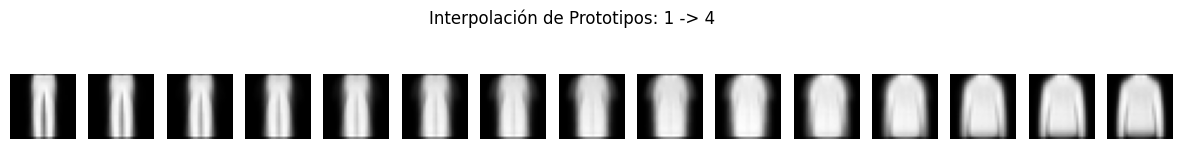

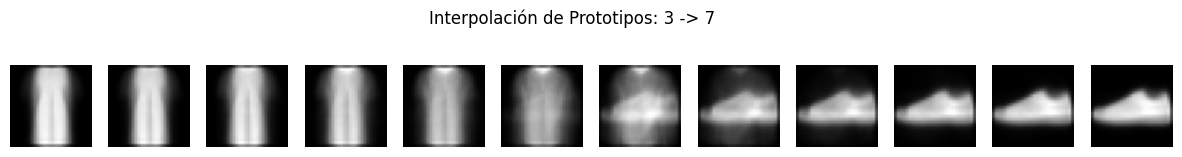

In [ ]:
#Ahora vamos a representar los vectores que interpolan dos clases para comprobar que el VAE funciona correctamente

# Seleccionamos las filas donde la etiqueta coincide con la clase
vectores_A = mus_array[labels_array == 1]
vectores_B = mus_array[labels_array == 4]

#print(f"Vectores A: {vectores_A}")
#print(f"Vectores B: {vectores_B}")

# Calculamos la media de esos vectores (el centroide del cluster)
prototipo_A = np.mean(vectores_A, axis=0)
prototipo_B = np.mean(vectores_B, axis=0)

fig, axes = plt.subplots(1, 15, figsize=(15, 2))
# Creamos 10 imagenes para cada vector
alphas = np.linspace(0, 1, 15)

with torch.no_grad():
  for i, alpha in enumerate(alphas):
    # Fórmula de interpolación lineal: v = A*(1-alpha) + B*alpha
    vector_inter = prototipo_A * (1 - alpha) + prototipo_B * alpha

    # Convertimos a tensor
    tensor = torch.tensor(vector_inter).float().to(device)
    tensor = tensor.unsqueeze(0) # Añadir dimensión de batch: (8) -> (1, 8)

    # Pasamos SOLO por el decodificador
    img_generada = model.decoder(tensor)

    # Procesar imagen para mostrar
    img_numpy = img_generada.cpu().squeeze().numpy()

    axes[i].imshow(img_numpy, cmap='gray')
    axes[i].axis('off')

plt.suptitle(f'Interpolación de Prototipos: 1 -> 4')
plt.show()


# Seleccionamos las filas donde la etiqueta coincide con la clase
vectores_A = mus_array[labels_array == 3]
vectores_B = mus_array[labels_array == 7]

#print(f"Vectores A: {vectores_A}")
#print(f"Vectores B: {vectores_B}")

# Calculamos la media de esos vectores (el centroide del cluster)
prototipo_A = np.mean(vectores_A, axis=0)
prototipo_B = np.mean(vectores_B, axis=0)

fig, axes = plt.subplots(1, 12, figsize=(15, 2))
# Creamos 10 imagenes para cada vector
alphas = np.linspace(0, 1, 12)

with torch.no_grad():
  for i, alpha in enumerate(alphas):
    # Fórmula de interpolación lineal: v = A*(1-alpha) + B*alpha
    vector_inter = prototipo_A * (1 - alpha) + prototipo_B * alpha

    # Convertimos a tensor
    tensor = torch.tensor(vector_inter).float().to(device)
    tensor = tensor.unsqueeze(0) # Añadir dimensión de batch: (8) -> (1, 8)

    # Pasamos SOLO por el decodificador
    img_generada = model.decoder(tensor)

    # Procesar imagen para mostrar
    img_numpy = img_generada.cpu().squeeze().numpy()

    axes[i].imshow(img_numpy, cmap='gray')
    axes[i].axis('off')

plt.suptitle(f'Interpolación de Prototipos: 3 -> 7')
plt.show()